In [ ]:
import pandas as pd
import numpy as np
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path

data_folder = Path.cwd() / "FCR_data_24"   
print("Folder:", data_folder)


Folder: c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\balacing_capacity_price\FCR_data_24


In [ ]:

# .xlsx files sort 
xlsx_files = sorted(data_folder.glob("*.xlsx"))
print("Found files:", xlsx_files)

if not xlsx_files:
    raise FileNotFoundError("No xlsx files found in FCR_data")

# read and stack
def read_fcr_file(f):
    return pd.read_excel(f)

df_all = pd.concat((read_fcr_file(f) for f in xlsx_files),
                   ignore_index=True)

# parse dates and sort
df_all["DATE_FROM"] = pd.to_datetime(df_all["DATE_FROM"], dayfirst=True)
df_all["DATE_TO"]   = pd.to_datetime(df_all["DATE_TO"],   dayfirst=True)
df_all = df_all.sort_values("DATE_FROM")

cols = [
    "DATE_FROM",
    "DATE_TO",
    "PRODUCT_TYPE",
    "TENDER_NUMBER",
    "PRODUCTNAME",
    "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]",
]
df_final = df_all[cols].reset_index(drop=True)

out_path = data_folder / "FCR_merged.xlsx"  
df_final.to_excel(out_path, index=False)


Found files: [WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_data_24/FCR_merged.xlsx'), WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_data_24/RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2024-01-01_2024-01-31.xlsx'), WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_data_24/RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2024-02-01_2024-02-29.xlsx'), WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_data_24/RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2024-03-01_2024-03-31.xlsx'), WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_data_24/RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2024-04-01_2024-04-30.xlsx'), WindowsPath('c:/Users/vkeenan/OneDrive - Delft University of Technology/Documents/balacing_capacity_price/FCR_dat

c:\Users\vkeenan\AppData\Local\miniconda3\envs\balancing\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\vkeenan\AppData\Local\miniconda3\envs\balancing\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\vkeenan\AppData\Local\miniconda3\envs\balancing\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\vkeenan\AppData\Local\miniconda3\envs\balancing\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply o

In [3]:
df_final = pd.read_excel(data_folder / "FCR_merged.xlsx")

In [ ]:
# all unique values
df_final["TENDER_NUMBER"].unique()

KEY_COLS = ["DATE_FROM", "DATE_TO", "PRODUCT_TYPE", "PRODUCTNAME"]
# prefer higher TENDER_NUMBER (2 over 1), keep one only per group
df_pref = (
    df_final
    .sort_values("TENDER_NUMBER", ascending=False)   # 2 before 1
    .drop_duplicates(subset=KEY_COLS, keep="first")  # keep preferred row
    .sort_values("DATE_FROM")                        
    .reset_index(drop=True)
)

In [5]:
print(df_pref.head())
print("-"*90)
print(df_pref.tail())

   DATE_FROM    DATE_TO PRODUCT_TYPE  TENDER_NUMBER   PRODUCTNAME  \
0 2024-01-01 2024-01-01          FCR              2  NEGPOS_20_24   
1 2024-01-01 2024-01-01          FCR              2  NEGPOS_12_16   
2 2024-01-01 2024-01-01          FCR              2  NEGPOS_08_12   
3 2024-01-01 2024-01-01          FCR              2  NEGPOS_04_08   
4 2024-01-01 2024-01-01          FCR              2  NEGPOS_00_04   

  NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]  
0                                             -  
1                                             -  
2                                             -  
3                                             -  
4                                             -  
------------------------------------------------------------------------------------------
      DATE_FROM    DATE_TO PRODUCT_TYPE  TENDER_NUMBER   PRODUCTNAME  \
2191 2024-12-31 2024-12-31          FCR              1  NEGPOS_16_20   
2192 2024-12-31 2024-12-31          FCR           

C:\Users\vkeenan\AppData\Local\Temp\ipykernel_8420\1629862697.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot[price_col].replace("-", np.nan),


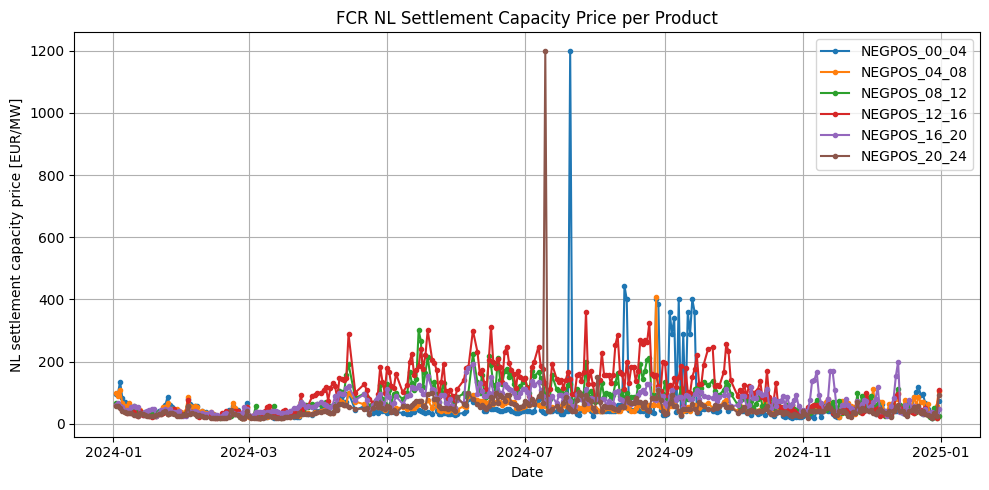

In [ ]:
df_plot = df_pref.copy()

df_plot["DATE_FROM"] = pd.to_datetime(df_plot["DATE_FROM"])

price_col = "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"
df_plot[price_col] = pd.to_numeric(
    df_plot[price_col].replace("-", np.nan),
    errors="coerce"
)

df_plot = df_plot.dropna(subset=[price_col])

plt.figure(figsize=(10, 5))

for name, g in df_plot.groupby("PRODUCTNAME"):
    plt.plot(g["DATE_FROM"], g[price_col], marker=".", label=name)

plt.xlabel("Date")
plt.ylabel("NL settlement capacity price [EUR/MW]")
plt.title("FCR NL Settlement Capacity Price per Product")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


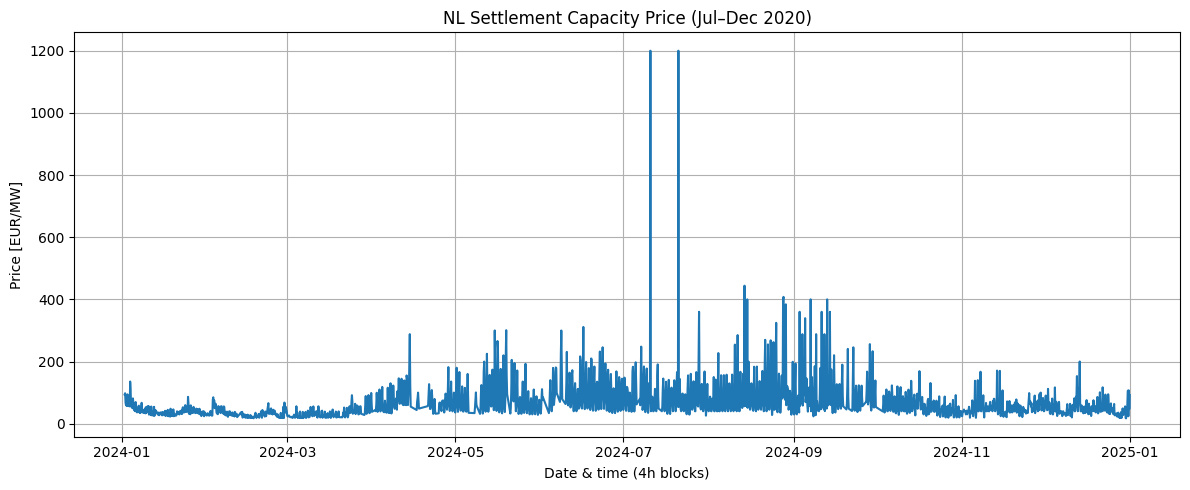

In [ ]:
df_plot["start_hour"] = (
    df_plot["PRODUCTNAME"].str.split("_").str[1].astype(int)
)

df_plot["timestamp"] = (
    df_plot["DATE_FROM"] + pd.to_timedelta(df_plot["start_hour"], "h")
)

df_plot = df_plot.sort_values("timestamp")

price_col = "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"

df_plot = df_plot.sort_values("timestamp").copy()
df_plot[price_col] = pd.to_numeric(
    df_plot[price_col].replace("-", np.nan), errors="coerce"
)
df_plot = df_plot.dropna(subset=[price_col])

plt.figure(figsize=(12,5))
plt.plot(df_plot["timestamp"], df_plot[price_col], linestyle="-")
plt.title("NL Settlement Capacity Price (Jul–Dec 2020)")
plt.xlabel("Date & time (4h blocks)")
plt.ylabel("Price [EUR/MW]")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
data_folder = Path.cwd()/"CSV"
df_pref.to_csv(data_folder/"FCR_NL2024.csv", index=False)
